### Import Dependencies

In [1]:
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langgraph.types import Send

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

import openai

from utils.utils import get_tool_descriptions, format_ai_message

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import Filter, FieldCondition, MatchValue, VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from langsmith import traceable

In [2]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [3]:
def get_embedding(text, model="text-embedding-3-small"):    
    response = openai.embeddings.create(
        input=text,
        model=model,
    )
    return response.data[0].embedding

In [4]:
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[0.5,0.5])),
        limit=k
    )

    retrieved_context_ids = []
    retieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [5]:
query = "Can I get a tablet?"

In [6]:
answer = retrieve_data(query, qdrant_client, k=10)

In [7]:
answer

{'retrieved_context_ids': ['B0B8NVNQKX',
  'B0B6VMB3D1',
  'B0C1NP5KYD',
  'B0BN7WWH63',
  'B0BR33XH8D',
  'B09LH466KZ',
  'B0BL2CZSHT',
  'B0B6ZZH83Y',
  'B0B4WCNWF3',
  'B0BFGXRMJN'],
 'retrieved_context': ['COOPERS 7 inch Kids Tablet Android 11 Tablet for Kids, 2GB RAM + 32GB ROM Toddler Tablet PC for Children, IPS Touch Screen, Dual Camera, Dual Speaker, WiFi Computer Tablet, Light Blue ✿【Good Kids tablet】This 7 inch tablet for kids with silm body and lightweight, it is easy to hold by children. Also the special design can protect the tablet well when dropping. ✿【Parental Control】Toddlers Tablet with parent mode can add or block apps. Set screen time limits. This tablet come with iwawa app. kids can get access to fun and educational games and videos. ✿【Powerful Tablets】Equipmented with quad core CPU, Android 11.0 System, 32GB Big Storage, 1024*600 IPS Screen offer a clear view. Runs Kinds of apps and game for kids smoothly. ✿【Long Lasting】Tablet for kids built with large capacity b

### Multi-intent Questions

In [8]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [9]:
answer = retrieve_data(query, qdrant_client, k=10)

In [10]:
answer

{'retrieved_context_ids': ['B0BRXZDBXZ',
  'B0BL2CZSHT',
  'B0B8NVNQKX',
  'B0C142QS8X',
  'B0C3XYD574',
  'B0BCQ8RJG7',
  'B09XQGN52P',
  'B0CFFGT7RM',
  'B09Q8FLNDR',
  'B0BFGXRMJN'],
 'retrieved_context': ["Kids Tablet, 7 inch Tablet for Kids 3GB RAM 32GB ROM, Android 11 Toddler Tablet with WiFi, Bluetooth, GMS, Parental Control, Shockproof Case, Google Play, YouTube, Netflix 【iWawa APP with parental control】This kids tablet has passed the GMS certification and is pre-installed with the iwawa app, specially designed for children. It has password control, remote video control, one-button lock screen and Learning, art, smart games. New-upgrade kids online school, fun interaction, video playback 【Android 11.0 & 128 GB Expand】Android 11.0 operating system, 3GB RAM 32GB ROM, support WiFi, Bluetooth, GPS, etc. The HD 1024*600IPS display can offer a perfect experience, You can expand the storage to 128 GB of SD cards for storing photos, music and videos. The upgraded battery can last more 

In [13]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [14]:
def query_expansion_node(query) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=QueryExpandResponse
    )
 
    return {
        "queries": response.statements
    }

In [15]:
answer = query_expansion_node(query)

In [16]:
answer

{'queries': ['Tablet for children', 'Watch for adults', 'Laptop for women']}

## LangGraph

### Query Expansion (Sequential Execution)

In [18]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

### Query Expansion / Rewriting Node

In [19]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [20]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=QueryExpandResponse
    )
 
    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [21]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):    
    response = openai.embeddings.create(
        input=text,
        model=model,
    )

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1,1])),
        limit=k
    )

    retrieved_context_ids = []
    retieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context


@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }

### Aggregator Node

In [22]:
class AggregatorResponse(BaseModel):
    answer: str

In [23]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=AggregatorResponse
    )
 
    return {
        "answer": response.answer
    }

In [24]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

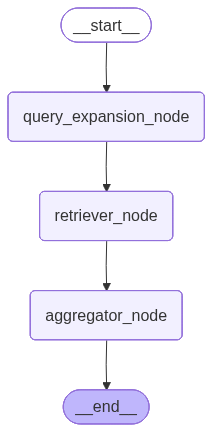

In [25]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query
}

In [31]:
result = graph.invoke(initial_state)

In [32]:
result

{'expanded_query': ['Tablet for kids', 'Watch for adults', 'Laptop for women'],
 'retrieved_context': ['- ID: B0C3XYD574, rating: 4.4, description: ROWT Tablet for Kids 10 inch Kids Tablet 2GB RAM 32GB ROM Android 11 6000mAh Wi-Fi, Bluetooth, Kid-Proof Case(Blue) 【Kids\' Safety & Parental Controls】Looking for a safe tablet that\'s easy for your kids to use? This 10-inch tablet for kids is GMS-certified, has password protection, a content filter, and a one-button lock screen, making it easier for parents to keep an eye on their kids activities and learning. 【Creative Educational Content】Our kids tablet provides access to a range of age-appropriate creative kids content such as drawing, educational games, eBooks, learning videos, math tools, and much more! Learning through play is best for kids to understand the world. 【Powerful Configuration & Full Access to Google】This Android 11 kids tablet has an HD 1280x800 IPS touchscreen, 1.6 GHz Quad-Core processor, 2GB RAM & 32GB ROM storage, du

In [33]:
print(result["answer"])

Based on the available products, here is a detailed description of the ROWT Tablet for Kids which fits the criteria of a child-friendly 10-inch tablet with parental controls and learning content:

- Product: ROWT Tablet for Kids 10 inch Kids Tablet (Blue)
- Operating System: Android 11
- Display: 10.1 inch HD 1280x800 IPS touchscreen with eye protection technology to reduce blue light damage for safer and more comfortable use
- Processor: 1.6 GHz Quad-Core processor
- Memory: 2GB RAM
- Storage: 32GB ROM
- Battery: Large capacity 6000mAh battery for long usage
- Connectivity: Wi-Fi and Bluetooth
- Cameras: Dual cameras
- Kid-Proof Case: Durable protective case with built-in stand to protect from scratches and bumps
- Safety Features: GMS-certified, password protection, content filter, one-button lock screen for parental controls
- Content: Comes with access to a range of creative educational content such as drawing, educational games, eBooks, learning videos, and math tools
- Google Acc

### Query Expansion (Parallel Execution)

In [34]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

### Query Expansion / Rewriting Node

In [35]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [36]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=QueryExpandResponse
    )
 
    return {
        "expanded_query": response.statements
    }

In [37]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages

### Retriever Node

In [38]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):    
    response = openai.embeddings.create(
        input=text,
        model=model,
    )

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=state["query"],
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1,1])),
        limit=state["k"]
    )

    retrieved_context_ids = []
    retieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Aggregator Node

In [39]:
class AggregatorResponse(BaseModel):
    answer: str

In [40]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=AggregatorResponse
    )
 
    return {
        "answer": response.answer
    }

In [41]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges("query_expansion_node", query_expand_conditional_edges)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

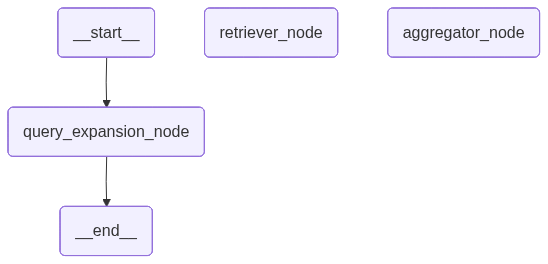

In [42]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query
}

In [44]:
result = graph.invoke(initial_state)

In [47]:
result

{'expanded_query': ['Tablet designed for children',
  'Personal watch',
  'Laptop for wife'],
 'retrieved_context': ['- ID: B0B8NVNQKX, rating: 3.6, description: COOPERS 7 inch Kids Tablet Android 11 Tablet for Kids, 2GB RAM + 32GB ROM Toddler Tablet PC for Children, IPS Touch Screen, Dual Camera, Dual Speaker, WiFi Computer Tablet, Light Blue ✿【Good Kids tablet】This 7 inch tablet for kids with silm body and lightweight, it is easy to hold by children. Also the special design can protect the tablet well when dropping. ✿【Parental Control】Toddlers Tablet with parent mode can add or block apps. Set screen time limits. This tablet come with iwawa app. kids can get access to fun and educational games and videos. ✿【Powerful Tablets】Equipmented with quad core CPU, Android 11.0 System, 32GB Big Storage, 1024*600 IPS Screen offer a clear view. Runs Kinds of apps and game for kids smoothly. ✿【Long Lasting】Tablet for kids built with large capacity battery. For mixed use up to 6 hours. You can enj

In [45]:
print(result["answer"])

Certainly! Here are some options for a kid's tablet, a watch for you, and a laptop for your wife from the available products:

Kid's Tablet Options:
1. COOPERS 7 inch Kids Tablet Android 11 Tablet for Kids
   - 7 inch IPS Touch Screen, 1024*600 resolution
   - Android 11.0 System, quad-core CPU
   - 2GB RAM, 32GB ROM
   - Dual Camera, Dual Speaker
   - Parental control with iwawa app
   - Battery lasts up to 6 hours
   - Light Blue with protective design

2. Fullant Kids Tablet 7 inch
   - Android 12 OS, 1.6GHz quad-core processor
   - 7 inch 1024x600 IPS HD display with eye protection
   - 2GB RAM, 32GB ROM, expandable up to 128GB
   - Bluetooth, Dual Camera
   - Shockproof silicone case with built-in kickstand
   - Up to 8 hours battery life

3. ROWT 10 inch Kids Tablet
   - 10.1 inch HD 1280x800 IPS display
   - Android 11, 1.6GHz quad-core CPU
   - 2GB RAM, 32GB ROM
   - Dual camera, large 6000mAh battery
   - Kid-proof case with built-in stand

Smart Watch Options for You:
1. Juge